# South African Municipal Financial Health

**Which municipalities are financially distressed — and what separates them from the healthy ones?**

Siyabonga Mfusi · Postgraduate Diploma in Data Analytics, IIE Varsity College

---

South Africa has 257 municipalities. They collect rates, deliver water and electricity, and
publish audited financial statements to the National Treasury every year. That data is public,
free, and almost nobody looks at it.

This notebook pulls seven datasets straight from the **Treasury's Municipal Money API** — no
key, no scraping, no download link — and builds a financial-health scorecard across every
municipality that reported for the 2024 financial year.

Four ratios, each one a standard measure a credit analyst would ask for:

| Ratio | What it measures | Treasury guidance |
|---|---|---|
| **Cash coverage** | Months of operating expenditure covered by cash on hand | 1 month minimum, 3 preferred |
| **Debt over 90 days** | Share of the debtor book that has aged past 90 days | Lower is better |
| **Operating margin** | Surplus as a share of revenue | Positive |
| **UIFW** | Unauthorised, irregular, fruitless and wasteful spend, as a share of expenditure | As close to zero as possible |

Then the question that matters: the Auditor-General publishes an opinion on each municipality.
**Does that opinion actually track financial reality, or is it a paperwork exercise?**

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
# Ordinal ramp for audit outcomes: one hue, light to dark = better to worse.
# Starts at step 250 so the lightest level still clears contrast on a white surface.
ORDINAL = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281", "#0d366b"]
INK, INK_DIM, GRID, MUTED = "#0b0b0b", "#52514e", "#e4e3df", "#c9c8c3"
GOOD, BAD = "#1baf7a", "#e34948"

mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": INK_DIM, "xtick.color": INK_DIM, "ytick.color": INK_DIM,
    "font.size": 11, "axes.titlesize": 12.5, "axes.titleweight": "bold",
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
})

# Resolve paths from the repo root, detected via a marker that always exists.
# Keying off the target directory would silently create outputs/ inside notebooks/
# on a fresh clone.
ROOT = Path("..") if (Path("..") / "src").exists() else Path(".")
DATA, OUTPUTS = ROOT / "data", ROOT / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)
YEAR = 2024
print("pandas", pd.__version__)

pandas 2.3.3


## 1. Assemble the panel

Seven separate API extracts, one row per municipality. Everything is joined on the Treasury's
`demarcation.code` — the official code for each municipality, which is what makes joining
government datasets possible at all.

In [2]:
muni = (pd.read_csv(DATA / "municipalities.csv")
          .rename(columns=lambda c: c.replace("municipality.", ""))
          .set_index("demarcation_code"))

ie    = pd.read_csv(DATA / "income_expenditure.csv")
cash  = pd.read_csv(DATA / "cash.csv")
debt  = pd.read_csv(DATA / "aged_debtors.csv")
uifw  = pd.read_csv(DATA / "uifw.csv")
audit = pd.read_csv(DATA / "audit_opinions.csv")
cap   = pd.read_csv(DATA / "capital.csv")

print(f"Municipalities on file : {len(muni)}")
print(muni.category.map({"A": "A  metropolitan", "B": "B  local", "C": "C  district"})
          .value_counts().sort_index().to_string())
print(f"\nProvinces: {muni.province_name.nunique()}")

Municipalities on file : 292
category
A  metropolitan      8
B  local           240
C  district         44

Provinces: 10


In [3]:
def year_slice(frame, year=YEAR):
    return frame[frame["financial_year_end.year"] == year]

ITEMS = {2900: "revenue", 4400: "expenditure", 4500: "surplus"}

fin = (year_slice(ie)
       .pivot_table(index="demarcation.code", columns="item.code", values="amount.sum")
       .rename(columns=ITEMS))

fin["cash"]  = year_slice(cash).set_index("demarcation.code")["amount.sum"]
fin["uifw"]  = year_slice(uifw).groupby("demarcation.code")["amount.sum"].sum()
fin["audit"] = year_slice(audit).set_index("demarcation.code")["opinion.label"]

d = year_slice(debt).set_index("demarcation.code")
fin["debtors_total"] = d["total_amount.sum"]
# "Over 90 days" is everything from the 91-120 bucket outward, plus debt older than a year
fin["debtors_over90"] = d[["l120_amount.sum", "l150_amount.sum",
                           "l180_amount.sum", "g1_amount.sum"]].sum(axis=1)

cp = year_slice(cap).pivot_table(index="demarcation.code", columns="amount_type.code",
                                 values="amount.sum")
fin["capex_actual"], fin["capex_budget"] = cp.get("AUDA"), cp.get("ADJB")

fin = fin.join(muni[["name", "long_name", "province_name", "category"]])
print(f"FY{YEAR} panel: {len(fin)} municipalities x {fin.shape[1]} columns")
fin.head(3)

FY2024 panel: 246 municipalities x 14 columns


,revenue,expenditure,surplus,cash,uifw,audit,debtors_total,debtors_over90,capex_actual,capex_budget,name,long_name,province_name,category
demarcation.code,,,,,,,,,,,,,,
BUF,9.353422e+09,1.077070e+10,-1.417275e+09,2.965732e+09,1.721930e+09,Qualified,1.544470e+10,1.044977e+10,3.493243e+09,2.409867e+09,Buffalo City,"Buffalo City, Eastern Cape",Eastern Cape,A
CPT,6.184149e+10,5.831392e+10,3.527564e+09,1.262441e+10,6.342620e+08,Unqualified - No findings,1.898819e+10,1.044543e+10,1.427807e+10,2.082522e+10,Cape Town,"Cape Town, Western Cape",Western Cape,A
DC1,5.550150e+08,5.464634e+08,8.551595e+06,2.530310e+08,5.393770e+05,Unqualified - No findings,2.521115e+07,2.347915e+06,7.941234e+07,1.849160e+08,West Coast,"West Coast, Western Cape",Western Cape,C


## 2. Build the ratios — and check them before trusting them

Government financial data is filed by hundreds of separate finance departments of wildly varying
capacity. Some of what comes back is not credible, and a scorecard that quietly averages
impossible numbers produces confident nonsense.

Every ratio below is computed first, then **audited against the range it can physically occupy**.

In [4]:
fin["cash_months"] = fin.cash / (fin.expenditure / 12)
fin["overdue_pct"] = fin.debtors_over90 / fin.debtors_total * 100
fin["op_margin"]   = fin.surplus / fin.revenue * 100
fin["uifw_pct"]    = fin.uifw / fin.expenditure * 100
fin["capex_exec"]  = fin.capex_actual / fin.capex_budget * 100

RATIOS = ["cash_months", "overdue_pct", "op_margin", "uifw_pct", "capex_exec"]
# The range each ratio can plausibly occupy. Outside this, the filing is not credible.
PLAUSIBLE = {
    "cash_months": (-24, 60),      # beyond 5 years of cash held is not a going concern signal
    "overdue_pct": (0, 100),       # a share of a total cannot exceed it
    "op_margin":   (-200, 100),    # a deficit twice revenue is already extreme
    "uifw_pct":    (0, 200),
    "capex_exec":  (0, 300),       # spending 3x an adjusted budget indicates a filing error
}

audit_rows = []
for r in RATIOS:
    s = fin[r]
    lo, hi = PLAUSIBLE[r]
    implausible = ((s < lo) | (s > hi)).sum()
    audit_rows.append({
        "ratio": r,
        "reported": int(s.notna().sum()),
        "missing": int(s.isna().sum()),
        "implausible": int(implausible),
        "min": round(s.min(), 1),
        "median": round(s.median(), 1),
        "max": round(s.max(), 1),
    })

quality = pd.DataFrame(audit_rows).set_index("ratio")
print(quality.to_string())

             reported  missing  implausible     min  median     max
ratio                                                              
cash_months       245        1           10   -54.1     3.9   131.5
overdue_pct       218       28            3    -0.3    80.5   295.7
op_margin         245        1            1 -2352.7   -12.2    44.3
uifw_pct          246        0            0     0.0    13.9   160.3
capex_exec        243        3           25     7.6    90.9  1851.4


Two things stand out.

`capex_exec` is the least trustworthy of the five — a meaningful number of municipalities report
capital spend wildly out of proportion to their adjusted budget, which is a filing artefact rather
than a real event. **It is kept in the data but excluded from the composite score.**

The rest are largely sound. Values outside the plausible range are set to missing rather than
clipped: a municipality reporting more than 100% of its debtor book as over-90-days has a
filing inconsistency, and inventing a value of exactly 100% for it would be fabrication.

In [5]:
clean = fin.copy()
for r in RATIOS:
    lo, hi = PLAUSIBLE[r]
    clean.loc[(clean[r] < lo) | (clean[r] > hi), r] = np.nan

removed = {r: int(fin[r].notna().sum() - clean[r].notna().sum()) for r in RATIOS}
print("Values voided as implausible:")
for r, n in removed.items():
    print(f"  {r:<13} {n}")
print(f"\nMunicipalities with all four core ratios usable: "
      f"{clean[['cash_months','overdue_pct','op_margin','uifw_pct']].notna().all(axis=1).sum()}")

Values voided as implausible:


  cash_months   10
  overdue_pct   3
  op_margin     1
  uifw_pct      0
  capex_exec    25

Municipalities with all four core ratios usable: 204


## 3. The national picture

Each ratio against the threshold that matters.

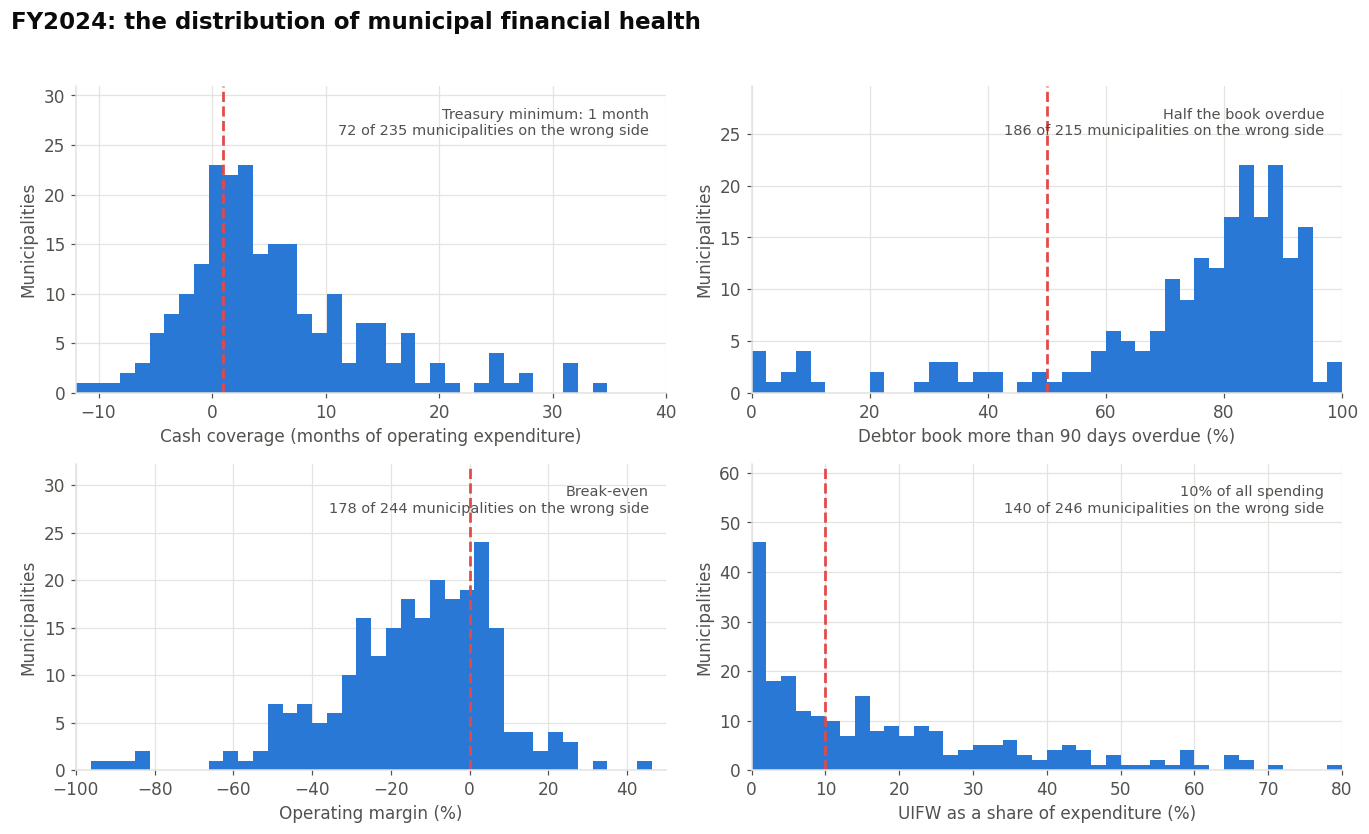

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.4))

specs = [
    ("cash_months", "Cash coverage (months of operating expenditure)", 1.0,
     "Treasury minimum: 1 month", "below", (-12, 40)),
    ("overdue_pct", "Debtor book more than 90 days overdue (%)", 50.0,
     "Half the book overdue", "above", (0, 100)),
    ("op_margin", "Operating margin (%)", 0.0,
     "Break-even", "below", (-100, 50)),
    ("uifw_pct", "UIFW as a share of expenditure (%)", 10.0,
     "10% of all spending", "above", (0, 80)),
]

for ax, (col, label, thresh, note, direction, xlim) in zip(axes.ravel(), specs):
    s = clean[col].dropna()
    ax.hist(s, bins=40, range=xlim, color=SERIES[0])
    ax.axvline(thresh, color=BAD, linewidth=1.8, linestyle="--")

    breached = (s < thresh).sum() if direction == "below" else (s > thresh).sum()
    ax.annotate(f"{note}\n{breached} of {len(s)} municipalities on the wrong side",
                xy=(0.97, 0.93), xycoords="axes fraction", ha="right", va="top",
                fontsize=9.5, color=INK_DIM)
    ax.set_xlabel(label)
    ax.set_ylabel("Municipalities")
    ax.set_xlim(*xlim)
    ax.set_ylim(top=ax.get_ylim()[1] * 1.28)   # headroom so the note clears the bars

fig.suptitle(f"FY{YEAR}: the distribution of municipal financial health",
             fontsize=15, fontweight="bold", x=0.007, ha="left", y=1.02)
fig.tight_layout()
fig.savefig(OUTPUTS / "figure_1_national_distributions.png")
plt.show()

In [7]:
core = ["cash_months", "overdue_pct", "op_margin", "uifw_pct"]
head = clean[core].median().round(2)
print("The median municipality in FY2024:")
print(f"  holds {head.cash_months:.1f} months of cash")
print(f"  has {head.overdue_pct:.0f}% of its debtor book more than 90 days overdue")
print(f"  runs an operating margin of {head.op_margin:+.1f}%")
print(f"  reports UIFW equal to {head.uifw_pct:.1f}% of its expenditure")
print()
n_cash = int((clean.cash_months < 1).sum()); tot_cash = int(clean.cash_months.notna().sum())
n_neg  = int((clean.cash_months < 0).sum())
print(f"{n_cash} of {tot_cash} municipalities hold less than one month of cash.")
print(f"{n_neg} of them ended the year with a negative cash position.")
print(f"Total UIFW reported in FY{YEAR}: R{fin.uifw.sum()/1e9:.1f} billion.")

The median municipality in FY2024:
  holds 3.7 months of cash
  has 80% of its debtor book more than 90 days overdue
  runs an operating margin of -12.2%
  reports UIFW equal to 13.9% of its expenditure

72 of 235 municipalities hold less than one month of cash.
54 of them ended the year with a negative cash position.
Total UIFW reported in FY2024: R61.9 billion.


## 4. Audit outcomes over a decade

The Auditor-General grades every municipality. Ordered from a clean opinion through to a
disclaimer — where the AG could not obtain enough evidence to form a view at all.

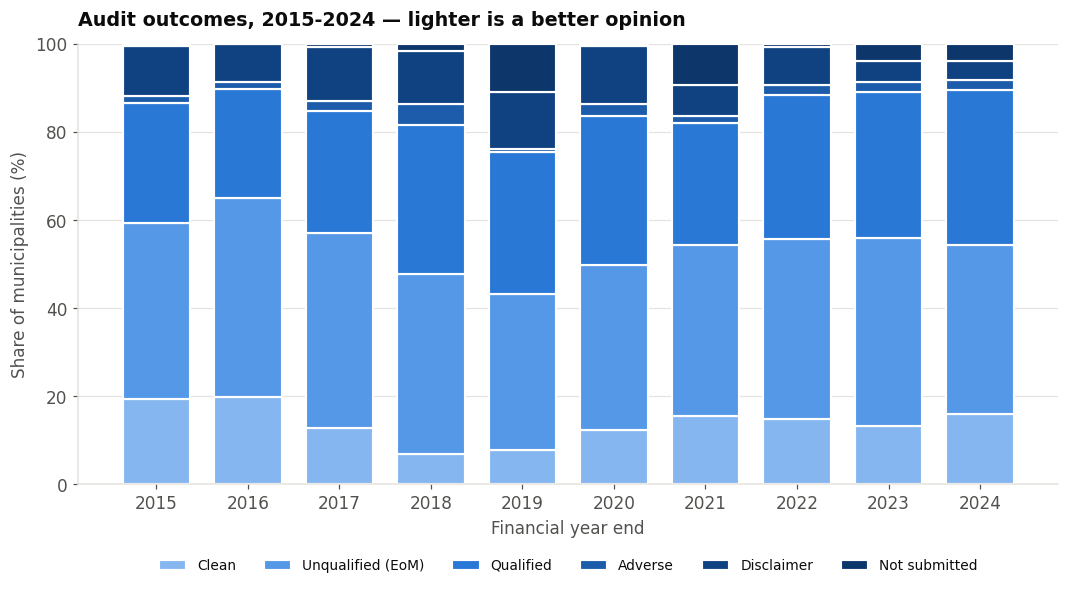

FY2024: 41 clean audits out of 257 (16.0%)


In [8]:
ORDER = ["Unqualified - No findings", "Unqualified - Emphasis of Matter items",
         "Qualified", "Adverse opinion", "Disclaimer of opinion", "Outstanding"]
SHORT = {"Unqualified - No findings": "Clean",
         "Unqualified - Emphasis of Matter items": "Unqualified (EoM)",
         "Qualified": "Qualified", "Adverse opinion": "Adverse",
         "Disclaimer of opinion": "Disclaimer", "Outstanding": "Not submitted"}

hist = (audit.groupby(["financial_year_end.year", "opinion.label"]).size()
             .unstack(fill_value=0).reindex(columns=ORDER, fill_value=0))
share = hist.div(hist.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11.5, 5.2))
bottom = np.zeros(len(share))
for i, col in enumerate(ORDER):
    ax.bar(share.index, share[col], bottom=bottom, color=ORDINAL[i],
           label=SHORT[col], width=0.74, edgecolor="white", linewidth=1.4)
    bottom += share[col].values

ax.set_ylabel("Share of municipalities (%)")
ax.set_xlabel("Financial year end")
ax.set_ylim(0, 100)
ax.set_xticks(share.index)
ax.set_title("Audit outcomes, 2015-2024 — lighter is a better opinion", loc="left", pad=12)
ax.legend(frameon=False, ncol=6, loc="upper center", bbox_to_anchor=(0.5, -0.14), fontsize=9)
ax.grid(axis="x", visible=False)

fig.savefig(OUTPUTS / "figure_2_audit_outcomes.png")
plt.show()

latest = hist.loc[YEAR]
print(f"FY{YEAR}: {latest['Unqualified - No findings']} clean audits out of {latest.sum()} "
      f"({latest['Unqualified - No findings']/latest.sum():.1%})")

## 5. Does the audit opinion track financial reality?

This is the question worth asking. An audit opinion is about whether the *books* are reliable,
not directly about whether the municipality is solvent. If the two are unrelated, the AG's
grade tells a resident nothing about their municipality's finances.

They are not unrelated.

In [9]:
GRADED = ORDER[:5]           # exclude "Outstanding" — no opinion was issued
sev = {o: i for i, o in enumerate(GRADED)}

g = clean[clean.audit.isin(GRADED)].copy()
g["severity"] = g.audit.map(sev)

by_audit = (g.groupby("audit")[core].median().reindex(GRADED))
by_audit["n"] = g.groupby("audit").size().reindex(GRADED)
by_audit.index = [SHORT[o] for o in by_audit.index]
print(by_audit.round(2).to_string())

print("\nSpearman rank correlation with audit severity:")
for c in core:
    s = g[["severity", c]].dropna()
    rho = s.severity.corr(s[c], method="spearman")
    print(f"  {c:<13} rho = {rho:+.3f}   (n = {len(s)})")

                   cash_months  overdue_pct  op_margin  uifw_pct   n
Clean                     6.68        61.56       0.93      0.79  41
Unqualified (EoM)         3.45        80.25      -8.86     11.78  98
Qualified                 3.03        84.15     -18.11     19.88  84
Adverse                   2.75        87.67     -28.36     31.26   5
Disclaimer                2.59        82.62     -35.06     27.78  10

Spearman rank correlation with audit severity:


  cash_months   rho = -0.184   (n = 227)
  overdue_pct   rho = +0.323   (n = 208)
  op_margin     rho = -0.389   (n = 237)
  uifw_pct      rho = +0.516   (n = 238)


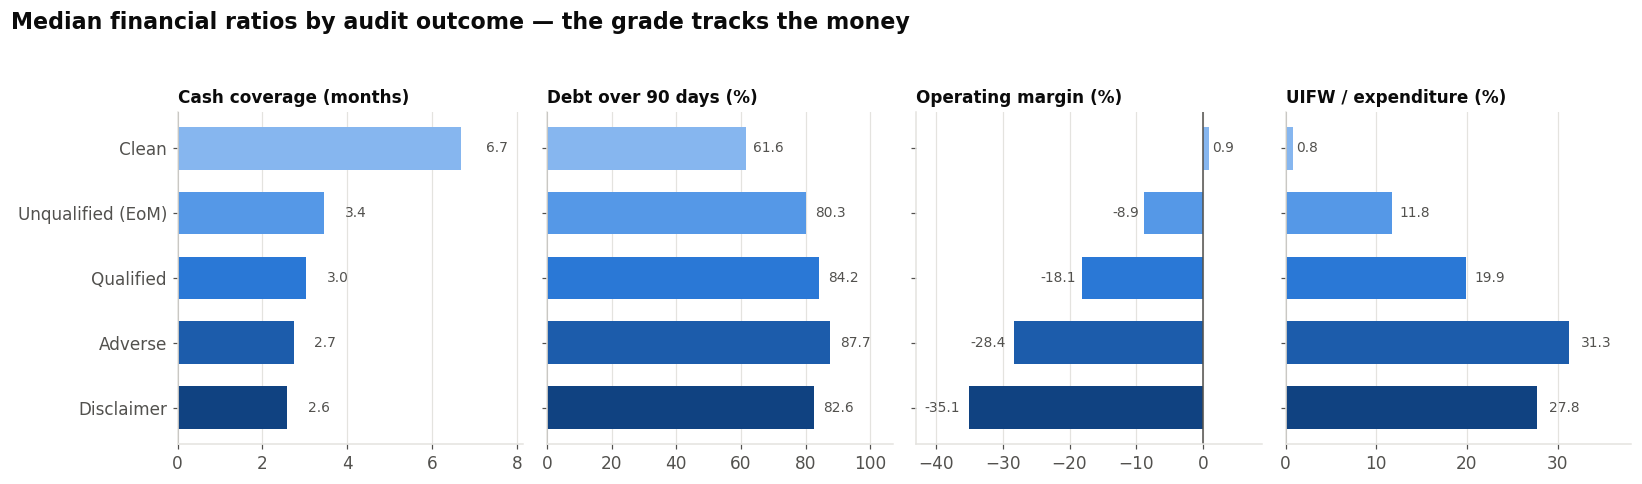

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4.2))

panels = [
    ("cash_months", "Cash coverage (months)", False),
    ("overdue_pct", "Debt over 90 days (%)", True),
    ("op_margin",   "Operating margin (%)", False),
    ("uifw_pct",    "UIFW / expenditure (%)", True),
]

ypos = np.arange(len(by_audit))
for ax, (col, label, higher_is_worse) in zip(axes, panels):
    vals = by_audit[col].values
    # Audit outcome keeps the same ordinal ramp it has in figure 2 — one variable,
    # one encoding, across every chart in the notebook.
    ax.barh(ypos, vals, color=ORDINAL[:len(ypos)], height=0.66)
    for y, v in zip(ypos, vals):
        ax.text(v + (abs(v) * 0.03 + 0.4) * (1 if v >= 0 else -1), y, f"{v:,.1f}",
                va="center", ha="left" if v >= 0 else "right", fontsize=9, color=INK_DIM)
    ax.set_yticks(ypos, by_audit.index if col == "cash_months" else [""] * len(ypos))
    ax.invert_yaxis()
    ax.set_title(label, loc="left", fontsize=11)
    ax.axvline(0, color=INK_DIM, linewidth=1)
    ax.grid(axis="y", visible=False)
    ax.margins(x=0.22)

fig.suptitle("Median financial ratios by audit outcome — the grade tracks the money",
             fontsize=14.5, fontweight="bold", x=0.007, ha="left", y=1.04)
fig.tight_layout()
fig.savefig(OUTPUTS / "figure_3_health_by_audit.png")
plt.show()

The ordering is monotonic on every ratio. Municipalities that earn a clean audit hold roughly
twice the cash, collect materially better, and are the only group that breaks even on average.

The sharpest divide is **UIFW**. A clean-audit municipality reports irregular and wasteful
spending near zero; the very next grade down reports it in double digits as a share of total
expenditure. That is not a gradual slope — it is a step change, and it is the single strongest
correlate of a worse audit opinion.

## 6. A composite distress score

Each ratio is converted to a **percentile rank** rather than a z-score. With outliers this
extreme, a z-score composite would be dominated by a handful of implausible filings; percentile
ranks are bounded and robust to exactly that.

`capex_exec` is excluded, for the data-quality reason established in section 2.

In [11]:
score = clean.copy()
DIRECTION = {"cash_months": 1, "op_margin": 1, "overdue_pct": -1, "uifw_pct": -1}

for c, sign in DIRECTION.items():
    score[f"pct_{c}"] = (score[c] * sign).rank(pct=True) * 100

pct_cols = [f"pct_{c}" for c in DIRECTION]
# Require at least three of the four ratios, so a municipality is not ranked on one number
score["health_score"] = score[pct_cols].mean(axis=1).where(score[pct_cols].notna().sum(axis=1) >= 3)
score["ratios_used"] = score[pct_cols].notna().sum(axis=1)

ranked = score.dropna(subset=["health_score"]).sort_values("health_score")
print(f"Scored {len(ranked)} municipalities (of {len(score)} in the panel)\n")

cols = ["long_name", "province_name", "category", "cash_months",
        "overdue_pct", "op_margin", "uifw_pct", "audit", "health_score"]
print("MOST DISTRESSED")
print(ranked[cols].head(10).round(1).to_string(index=False))
print("\nHEALTHIEST")
print(ranked[cols].tail(10).iloc[::-1].round(1).to_string(index=False))

Scored 244 municipalities (of 246 in the panel)

MOST DISTRESSED
                      long_name province_name category  cash_months  overdue_pct  op_margin  uifw_pct                                  audit  health_score
     Tsantsabane, Northern Cape Northern Cape        B         -4.4          NaN      -84.8      41.1                  Disclaimer of opinion           8.2
    Joe Morolong, Northern Cape Northern Cape        B         -5.8         91.4      -45.1      41.4                              Qualified          10.0
         Dipaleseng, Mpumalanga    Mpumalanga        B          0.2         93.5      -31.4      61.5                              Qualified          13.5
     Kgetlengrivier, North West    North West        B          2.0          NaN      -58.3      65.2                              Qualified          14.9
      Victor Khanye, Mpumalanga    Mpumalanga        B          1.7          NaN      -48.1      58.2                              Qualified          16.1
     

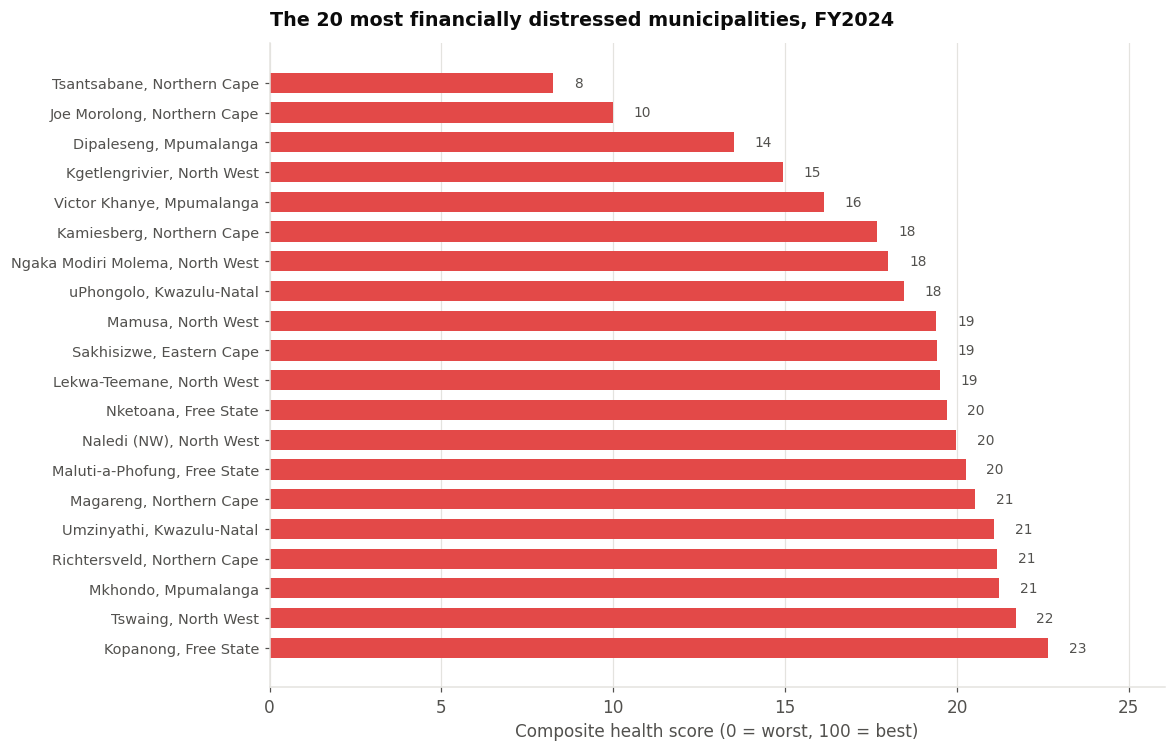

In [12]:
worst = ranked.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(10.5, 7.6))

y = np.arange(len(worst))
ax.barh(y, worst.health_score, color=BAD, height=0.68)
for yi, (v, aud) in enumerate(zip(worst.health_score, worst.audit)):
    ax.text(v + 0.6, yi, f"{v:.0f}", va="center", fontsize=9, color=INK_DIM)

labels = [f"{r.long_name[:38]}" for r in worst.itertuples()]
ax.set_yticks(y, labels, fontsize=9.5)
ax.set_xlabel("Composite health score (0 = worst, 100 = best)")
ax.set_title(f"The 20 most financially distressed municipalities, FY{YEAR}", loc="left", pad=12)
ax.grid(axis="y", visible=False)
ax.set_xlim(0, max(worst.health_score) * 1.15)

fig.savefig(OUTPUTS / "figure_4_distress_ranking.png")
plt.show()

## 7. The metros

Eight metropolitan municipalities serve roughly 40% of South Africa's population and account for
the majority of municipal spending. They are worth separating out — a district municipality with
weak finances is a local problem, and a metro with weak finances is a national one.

In [13]:
metros = score[score.category == "A"].sort_values("cash_months")
mcols = ["name", "cash_months", "overdue_pct", "op_margin", "uifw_pct", "audit", "health_score"]
print(metros[mcols].round(1).to_string(index=False))

                name  cash_months  overdue_pct  op_margin  uifw_pct                                  audit  health_score
  City of Ekurhuleni         -1.5         64.1       -3.5       1.0 Unqualified - Emphasis of Matter items          61.5
City of Johannesburg          0.6          NaN       -5.2       6.3 Unqualified - Emphasis of Matter items          52.1
           eThekwini          2.1          NaN       -1.1       2.9 Unqualified - Emphasis of Matter items          62.0
  Nelson Mandela Bay          2.5         81.5       -7.0      19.5                              Qualified          46.6
           Cape Town          2.6         55.0        5.7       1.1              Unqualified - No findings          75.2
        Buffalo City          3.3         67.7      -15.2      16.0                              Qualified          52.9
            Mangaung          8.4         75.2      -12.9      16.3                              Qualified          56.3
     City of Tshwane         21.

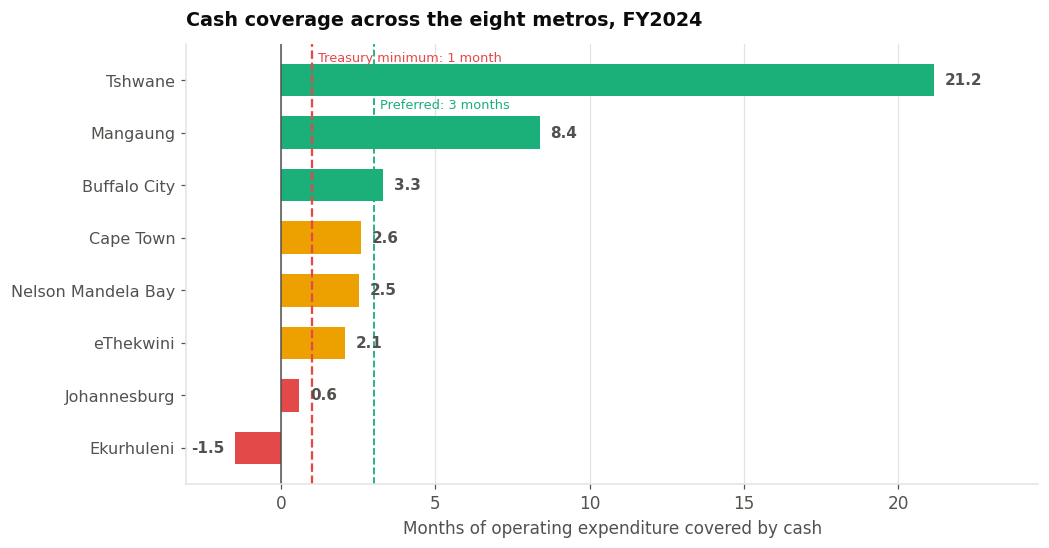

In [14]:
# Horizontal bars: eight metro names will not fit side by side on a category axis
fig, ax = plt.subplots(figsize=(10, 5.2))

m = metros.dropna(subset=["cash_months"]).sort_values("cash_months")
colours = [BAD if v < 1 else (SERIES[3] if v < 3 else GOOD) for v in m.cash_months]

y = np.arange(len(m))
ax.barh(y, m.cash_months, color=colours, height=0.62)

for yi, v in zip(y, m.cash_months):
    ax.text(v + (0.35 if v >= 0 else -0.35), yi, f"{v:.1f}",
            va="center", ha="left" if v >= 0 else "right",
            fontsize=10, fontweight="bold", color=INK_DIM)

ax.axvline(1, color=BAD, linestyle="--", linewidth=1.5)
ax.axvline(3, color=GOOD, linestyle="--", linewidth=1.2)
ax.axvline(0, color=INK_DIM, linewidth=1)

# The two thresholds sit only 2 units apart on a ~22-unit axis, so their labels are
# staggered vertically rather than placed side by side
ax.text(1.2, len(m) - 0.45, "Treasury minimum: 1 month", fontsize=8.5, color=BAD, va="top")
ax.text(3.2, len(m) - 1.35, "Preferred: 3 months", fontsize=8.5, color=GOOD, va="top")

ax.set_yticks(y, [n.replace("City of ", "") for n in m.name], fontsize=10.5)
ax.set_xlabel("Months of operating expenditure covered by cash")
ax.set_title(f"Cash coverage across the eight metros, FY{YEAR}", loc="left", pad=12)
# Extra room on the left so a negative bar's value label clears the tick labels
ax.set_xlim(min(m.cash_months.min() - 1.6, -2.6), m.cash_months.max() * 1.16)
ax.grid(axis="y", visible=False)

fig.savefig(OUTPUTS / "figure_5_metros.png")
plt.show()

In [15]:
prov = (score.groupby("province_name")
             .agg(municipalities=("health_score", "size"),
                  scored=("health_score", "count"),
                  median_health=("health_score", "median"),
                  median_cash=("cash_months", "median"),
                  median_uifw=("uifw_pct", "median"))
             .sort_values("median_health"))
print(prov.round(1).to_string())

export = score.reset_index().rename(columns={"index": "demarcation_code"})
keep = ["demarcation_code", "long_name", "province_name", "category", "revenue", "expenditure",
        "cash_months", "overdue_pct", "op_margin", "uifw_pct", "capex_exec",
        "audit", "health_score", "ratios_used"]
export[[c for c in keep if c in export.columns]].to_csv(OUTPUTS / "municipal_scorecard.csv",
                                                        index=False)
by_audit.to_csv(OUTPUTS / "health_by_audit_outcome.csv")
print(f"\nExported scorecard for {len(export)} municipalities")

               municipalities  scored  median_health  median_cash  median_uifw
province_name                                                                 
Free State                 19      18           37.7          2.0         17.1
North West                 20      19           38.7          6.5         27.7
Northern Cape              28      28           41.0          2.2         18.9
Mpumalanga                 19      19           41.5          2.2         15.4
Eastern Cape               38      38           51.0          2.8         10.7
Kwazulu-Natal              54      54           53.2          4.8         12.9
Limpopo                    27      27           53.4          4.0          9.4
Gauteng                    11      11           54.4          0.8          8.7
Western Cape               30      30           75.2          5.6          3.7

Exported scorecard for 246 municipalities


## 8. Findings

**One in three municipalities cannot cover a month of operating costs.** Treasury's guidance is a
one-month cash buffer as an absolute floor. A large share of the sector sits below it, and a
substantial number ended the year with negative cash — meaning they were spending money they did
not have.

**Debtor collection has broken down sector-wide.** The median municipality carries roughly 80% of
its debtor book past 90 days. This is not a handful of poorly run councils; it is the normal
condition. Revenue that appears on the statement of financial performance is substantially not
cash the municipality will ever see.

**The audit opinion is a real signal, not a paperwork exercise.** Median cash, collection,
operating margin and UIFW all worsen monotonically as the opinion deteriorates. For a resident or
a lender wanting one number, the AG's grade carries genuine information about the money.

**UIFW is the sharpest dividing line.** The gap between a clean audit and the next grade down is a
step change rather than a slope, and UIFW is the strongest rank correlate of audit severity among
the four ratios tested. Irregular expenditure is not a technicality — it travels with everything
else going wrong.

### Limitations

This is **reported** data. A municipality with collapsed financial controls is also the one least
able to file accurate figures, so the worst cases are likely understated rather than overstated —
the bias runs toward optimism exactly where scepticism is most warranted. Municipalities that
failed to submit at all are absent from the ratios entirely, which means the sector-wide picture
here is, if anything, flattering.

The composite score weights its four ratios equally. That is a defensible default and not a
derived truth; a credit analyst would weight cash coverage more heavily, and the ranking would
shift accordingly.

Ratios are single-year snapshots. A municipality can look solvent in one year on the back of a
grant payment that arrived before year end.

### Reproducing

```bash
pip install -r requirements.txt
python src/fetch_data.py     # pulls from the Treasury API; data/ is committed, so optional
jupyter notebook notebooks/municipal_financial_health.ipynb
```

**Data:** [National Treasury Municipal Money API](https://municipaldata.treasury.gov.za/) — public,
no API key. Audited actuals for the 2024 financial year, audit opinions 2015-2024.